In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv("ai_student_impact_dataset.csv")
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [4]:
def get_usage(h):
    if h == 0:
        return "None"
    elif h < 5:
        return "Low"
    elif h < 15:
        return "Medium"
    else:
        return "High"

df["Usage"] = df["Weekly_GenAI_Hours"].apply(get_usage)

df["Policy"] = df["Institutional_Policy"].map({
    "Strict_Ban": "Strict ban",
    "Allowed_With_Citation": "Allowed with citation",
    "Actively_Encouraged": "Actively encouraged"
})

order = ["Strict ban", "Allowed with citation", "Actively encouraged"]

In [5]:
def bar_plot(data, title, ylabel, color):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7,4))

    colors = ["red", "green", "blue"]
    bars = plt.bar(data.index, data.values, color=colors)

    for b, v in zip(bars, data.values):
        plt.text(b.get_x()+0.15, v, f"{v:.2f}")

    plt.title(title)
    plt.ylabel(ylabel)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

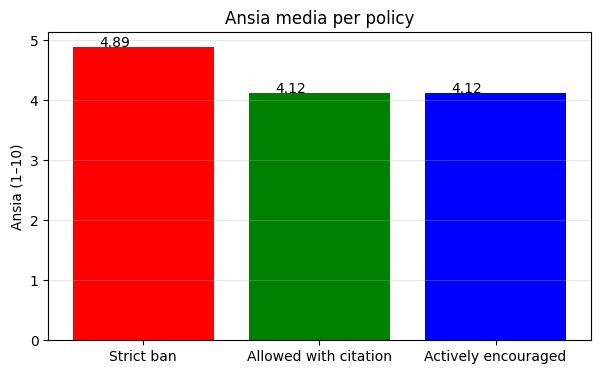

In [6]:
h1 = df.groupby("Policy")["Anxiety_Level_During_Exams"].mean().loc[order]
bar_plot(h1, "Ansia media per policy", "Ansia (1–10)", "skyblue")

prima ipotesi: nelle scuole con regole più rigide sull’IA gli studenti sono in media più ansiosi rispetto a quelle più permissive.

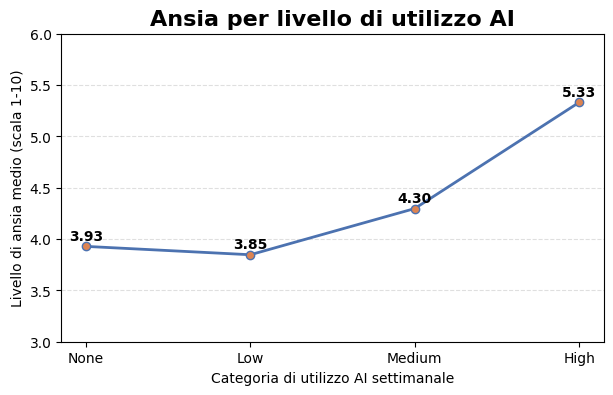

In [7]:
h2 = df.groupby("Usage")["Anxiety_Level_During_Exams"].mean()

# Optional: enforce logical order
usage_order = ["None", "Low", "Medium", "High"]
h2 = h2.loc[usage_order]

plt.figure(figsize=(7,4))

plt.plot(
    h2.index,
    h2.values,
    marker="o",
    color="#4C72B0",
    linewidth=2,
    markerfacecolor="#DD8452"
)

# Add values above points
for x, y in zip(h2.index, h2.values):
    plt.text(
        x,
        y + 0.03,       # small vertical offset
        f"{y:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Ansia per livello di utilizzo AI", fontsize=16, fontweight="bold")
plt.xlabel("Categoria di utilizzo AI settimanale")
plt.ylabel("Livello di ansia medio (scala 1-10)")
plt.ylim(3, 6)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

seconda ipotesi : chi usa più spesso l’IA tende ad avere più ansia rispetto a chi la usa poco.

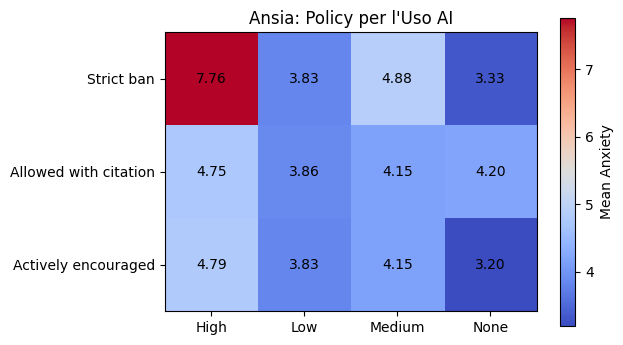

In [8]:
heat = df.pivot_table(
    index="Policy",
    columns="Usage",
    values="Anxiety_Level_During_Exams"
)

heat = heat.loc[order]

plt.figure(figsize=(6,4))
plt.imshow(heat, cmap="coolwarm")

plt.xticks(range(len(heat.columns)), heat.columns)
plt.yticks(range(len(heat.index)), heat.index)

# Add numbers to each cell
for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        value = heat.iloc[i, j]
        plt.text(
            j, i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.title("Ansia: Policy per l'Uso AI")
plt.colorbar(label="Mean Anxiety")
plt.show()

terza potesi: l’ansia è molto alta soprattutto tra chi usa tanto l’IA e sta in scuole con divieto. Quindi sembra che il problema non sia l’IA in sé, ma quanto ci si abitua a usarla.

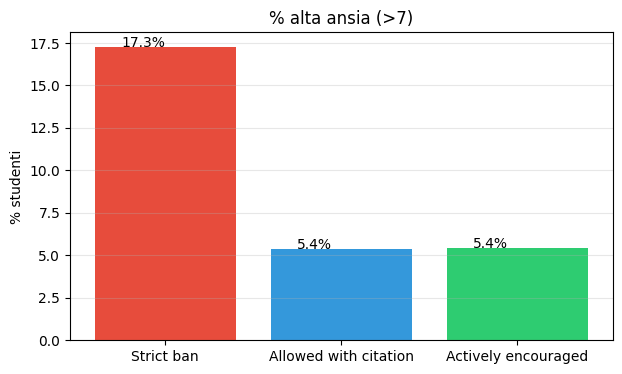

In [9]:
high = df.groupby("Policy")["Anxiety_Level_During_Exams"].apply(lambda x: (x>7).mean()*100).loc[order]

plt.figure(figsize=(7,4))
colors = ["#e74c3c", "#3498db", "#2ecc71"]
bars = plt.bar(high.index, high.values, color=colors)

for b, v in zip(bars, high.values):
    plt.text(b.get_x()+0.15, v, f"{v:.1f}%")

plt.title("% alta ansia (>7)")
plt.ylabel("% studenti")
plt.grid(axis="y", alpha=0.3)
plt.show()

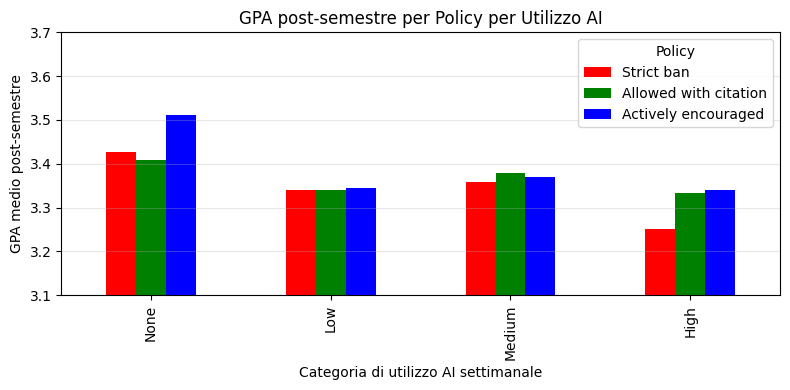

In [10]:
gpa_pivot = df.pivot_table(
    index="Usage",
    columns="Policy",
    values="Post_Semester_GPA",
    aggfunc="mean"
).loc[["None", "Low", "Medium", "High"], order]

gpa_pivot.plot(
    kind="bar",
    figsize=(8,4),
    color=["red", "green", "blue"]
)

plt.title("GPA post-semestre per Policy per Utilizzo AI")
plt.xlabel("Categoria di utilizzo AI settimanale")
plt.ylabel("GPA medio post-semestre")
plt.ylim(3.1, 3.7)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Policy")

plt.tight_layout()
plt.show()

Per i voti invece le differenze sono piccole, però chi ha più ansia tende ad andare leggermente peggio.